In [1]:
import os
os.path.exists('../data/forecasting data/macro_yahoo_vix_yieldcurve_dxy.csv')

True

In [2]:
import pandas as pd
import numpy as np

In [3]:
yfdf = pd.read_csv('../data/forecasting data/macro_yahoo_vix_yieldcurve_dxy.csv')

macrodf = pd.read_csv('../data/forecasting data/merged_macro_dataset.csv')

tipsdf = pd.read_csv('../data/forecasting data/us_treasury_tips_breakeven.csv')

In [4]:
yfdf.head()

,Date,VIX,UST10Y_pct,DX_FUT
0,1980-01-02,NaN,1.050,NaN
1,1980-01-03,NaN,1.060,NaN
2,1980-01-04,NaN,1.066,NaN
3,1980-01-07,NaN,1.063,NaN
4,1980-01-08,NaN,1.057,NaN


In [5]:
macrodf.head()

,date,inflation_factor,growth_factor,ppi_commodities,oil_price,broad_dollar_index,unemployment_rate,nonfarm_payrolls,avg_weekly_hours_manufacturing,housing_starts_total,fed_funds_rate,treasury_10y_yield,aaa_corp_yield,baa_corp_yield,consumer_sentiment,sp500_index
0,1990-01-01,0.757146,-0.505780,133.8,22.641,109.356760,5.4,109196,40.5,1551,8.23,8.21,8.99,9.94,93.0,339.97
1,1990-02-01,0.440626,0.908163,128.1,22.108,109.406583,5.3,109436,40.6,1437,8.24,8.47,9.22,10.14,89.5,330.45
2,1990-03-01,0.377480,0.498157,132.9,20.418,111.612134,5.2,109640,40.6,1289,8.28,8.59,9.37,10.21,91.3,338.46
3,1990-04-01,0.210052,-0.261981,139.6,18.582,111.606572,5.4,109674,40.4,1248,8.26,8.79,9.46,10.30,93.9,338.18
4,1990-05-01,0.224825,0.304152,138.4,18.237,110.079479,5.4,109828,40.6,1212,8.18,8.76,9.47,10.41,90.6,350.25


In [6]:
tipsdf.head()

,date,5Y_nominal,10Y_nominal,30Y_nominal,5Y_real,10Y_real,30Y_real,5Y_breakeven,10Y_breakeven,30Y_breakeven
0,1970-01-02,8.19,7.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-05,8.19,7.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1970-01-06,8.26,7.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1970-01-07,8.30,7.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1970-01-08,8.25,7.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Standardize column names to lowercase
yfdf.columns = yfdf.columns.str.lower()
tipsdf.columns = tipsdf.columns.str.lower()
macrodf.columns = macrodf.columns.str.lower()

# Now merge on 'date'
merged_df = yfdf.merge(tipsdf, on='date', how='outer')

# Convert date to datetime if not already
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Filter to start from 1980-01-01
start_date = pd.to_datetime('1980-01-01')
merged_df = merged_df[merged_df['date'] >= start_date].reset_index(drop=True)

print(f"merged_df shape: {merged_df.shape}")
print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")
print(merged_df.head())

merged_df shape: (11586, 13)
Date range: 1980-01-02 00:00:00 to 2025-12-02 00:00:00
        date  vix  ust10y_pct  dx_fut  5y_nominal  10y_nominal  30y_nominal  \
0 1980-01-02  NaN       1.050     NaN       10.52        10.50        10.23   
1 1980-01-03  NaN       1.060     NaN       10.54        10.60        10.31   
2 1980-01-04  NaN       1.066     NaN       10.62        10.66        10.34   
3 1980-01-07  NaN       1.063     NaN       10.56        10.63        10.35   
4 1980-01-08  NaN       1.057     NaN       10.52        10.57        10.28   

   5y_real  10y_real  30y_real  5y_breakeven  10y_breakeven  30y_breakeven  
0      NaN       NaN       NaN           NaN            NaN            NaN  
1      NaN       NaN       NaN           NaN            NaN            NaN  
2      NaN       NaN       NaN           NaN            NaN            NaN  
3      NaN       NaN       NaN           NaN            NaN            NaN  
4      NaN       NaN       NaN           NaN            

In [8]:
macrodf = pd.read_csv('../data/macro_final/final_macro.csv')

In [9]:
macrodf['date'] = pd.to_datetime(macrodf['date'])
macrodf = macrodf.set_index('date')

merged_df['date'] = pd.to_datetime(merged_df['date'])
merged_df = merged_df.set_index('date')

In [10]:
macrodf = macrodf.copy()
merged_df = merged_df.copy()

macrodf['month'] = macrodf.index.to_period('M')
merged_df['month'] = merged_df.index.to_period('M')

In [11]:
macrodf.head()

,inflation_factor,growth_factor,monetary_policy_factor,market_volatility_factor,month
date,,,,,
1990-01-01,0.757146,-0.505780,8.23,22.29,1990-01
1990-02-01,0.440626,0.908163,8.24,22.29,1990-02
1990-03-01,0.377480,0.498157,8.28,22.29,1990-03
1990-04-01,0.210052,-0.261981,8.26,22.29,1990-04
1990-05-01,0.224825,0.304152,8.18,22.29,1990-05


In [12]:
merged_df.head()

,vix,ust10y_pct,dx_fut,5y_nominal,10y_nominal,30y_nominal,5y_real,10y_real,30y_real,5y_breakeven,10y_breakeven,30y_breakeven,month
date,,,,,,,,,,,,,
1980-01-02,NaN,1.050,NaN,10.52,10.50,10.23,NaN,NaN,NaN,NaN,NaN,NaN,1980-01
1980-01-03,NaN,1.060,NaN,10.54,10.60,10.31,NaN,NaN,NaN,NaN,NaN,NaN,1980-01
1980-01-04,NaN,1.066,NaN,10.62,10.66,10.34,NaN,NaN,NaN,NaN,NaN,NaN,1980-01
1980-01-07,NaN,1.063,NaN,10.56,10.63,10.35,NaN,NaN,NaN,NaN,NaN,NaN,1980-01
1980-01-08,NaN,1.057,NaN,10.52,10.57,10.28,NaN,NaN,NaN,NaN,NaN,NaN,1980-01


In [13]:
# Aggregate merged_df from daily to monthly frequency (taking average)
merged_df_monthly = merged_df.reset_index()
merged_df_monthly['month'] = merged_df_monthly['date'].dt.to_period('M')

# Group by month and take the average of each month
merged_df_monthly = merged_df_monthly.groupby('month').mean(numeric_only=True).reset_index()
merged_df_monthly['date'] = merged_df_monthly['month'].dt.to_timestamp()

print(f"merged_df_monthly shape: {merged_df_monthly.shape}")
print(f"Date range: {merged_df_monthly['date'].min()} to {merged_df_monthly['date'].max()}")
print(merged_df_monthly.head())

# Now align both dataframes on date
macrodf_reset = macrodf.reset_index()
combined_df = merged_df_monthly.merge(macrodf_reset, on='date', how='inner')

print(f"\nCombined df shape: {combined_df.shape}")
print(f"Date range: {combined_df['date'].min()} to {combined_df['date'].max()}")


merged_df_monthly shape: (552, 14)
Date range: 1980-01-01 00:00:00 to 2025-12-01 00:00:00
     month  vix  ust10y_pct  dx_fut  5y_nominal  10y_nominal  30y_nominal  \
0  1980-01  NaN    1.080227     NaN   10.743636    10.802273    10.595000   
1  1980-02  NaN    1.241474     NaN   12.596316    12.414737    12.133158   
2  1980-03  NaN    1.274905     NaN   13.469524    12.749048    12.339048   
3  1980-04  NaN    1.147333     NaN   11.843810    11.473333    11.400000   
4  1980-05  NaN    1.018143     NaN    9.945714    10.181429    10.361429   

   5y_real  10y_real  30y_real  5y_breakeven  10y_breakeven  30y_breakeven  \
0      NaN       NaN       NaN           NaN            NaN            NaN   
1      NaN       NaN       NaN           NaN            NaN            NaN   
2      NaN       NaN       NaN           NaN            NaN            NaN   
3      NaN       NaN       NaN           NaN            NaN            NaN   
4      NaN       NaN       NaN           NaN            N

In [14]:
combined_df.head()

,month_x,vix,ust10y_pct,dx_fut,5y_nominal,10y_nominal,30y_nominal,5y_real,10y_real,30y_real,5y_breakeven,10y_breakeven,30y_breakeven,date,inflation_factor,growth_factor,monetary_policy_factor,market_volatility_factor,month_y
0,1990-01,23.347273,0.820667,NaN,8.119524,8.206667,8.258571,NaN,NaN,NaN,NaN,NaN,NaN,1990-01-01,0.757146,-0.505780,8.23,22.29,1990-01
1,1990-02,23.262632,0.847316,NaN,8.424737,8.473158,8.503684,NaN,NaN,NaN,NaN,NaN,NaN,1990-02-01,0.440626,0.908163,8.24,22.29,1990-02
2,1990-03,20.062273,0.858864,NaN,8.600455,8.588636,8.563182,NaN,NaN,NaN,NaN,NaN,NaN,1990-03-01,0.377480,0.498157,8.28,22.29,1990-03
3,1990-04,21.403500,0.878550,NaN,8.768000,8.785500,8.756000,NaN,NaN,NaN,NaN,NaN,NaN,1990-04-01,0.210052,-0.261981,8.26,22.29,1990-04
4,1990-05,18.097727,0.875818,NaN,8.735909,8.758182,8.731364,NaN,NaN,NaN,NaN,NaN,NaN,1990-05-01,0.224825,0.304152,8.18,22.29,1990-05


# Test-Train Split

In [15]:
from sklearn.model_selection import train_test_split

# Define features (from merged_df) and targets (from macrodf)
# Exclude date and month columns
feature_cols = [col for col in merged_df_monthly.columns if col not in ['date', 'month']]
target_cols = [col for col in macrodf_reset.columns if col not in ['date', 'month']]

print(f"Feature columns: {feature_cols}")
print(f"Target columns: {target_cols}")

# Prepare X (features) and y (targets)
X = combined_df[feature_cols].fillna(combined_df[feature_cols].mean())
y = combined_df[target_cols].fillna(combined_df[target_cols].mean())

# Train-test split (80-20, shuffle=False to preserve time series order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"\nTrain set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set shape: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nX_train date range: {combined_df.iloc[X_train.index]['date'].min()} to {combined_df.iloc[X_train.index]['date'].max()}")
print(f"X_test date range: {combined_df.iloc[X_test.index]['date'].min()} to {combined_df.iloc[X_test.index]['date'].max()}")

Feature columns: ['vix', 'ust10y_pct', 'dx_fut', '5y_nominal', '10y_nominal', '30y_nominal', '5y_real', '10y_real', '30y_real', '5y_breakeven', '10y_breakeven', '30y_breakeven']
Target columns: ['inflation_factor', 'growth_factor', 'monetary_policy_factor', 'market_volatility_factor']

Train set shape: X_train (342, 12), y_train (342, 4)
Test set shape: X_test (86, 12), y_test (86, 4)

X_train date range: 1990-01-01 00:00:00 to 2018-06-01 00:00:00
X_test date range: 2018-07-01 00:00:00 to 2025-08-01 00:00:00


# Random Forest

RANDOM FOREST MODEL PERFORMANCE (Regularized)

Training Set:
  R² Score: 0.5992
  RMSE: 1.3933
  MAE: 0.6469

Test Set:
  R² Score: 0.1879
  RMSE: 2.5374
  MAE: 1.3644

Overfitting Gap (Train R² - Test R²): 0.4113
OOB Score: 0.4814

Top 15 Most Important Features:
          feature  importance
0             vix    0.441379
9    5y_breakeven    0.144418
10  10y_breakeven    0.093280
3      5y_nominal    0.055067
4     10y_nominal    0.051034
1      ust10y_pct    0.045688
5     30y_nominal    0.045269
7        10y_real    0.041230
2          dx_fut    0.033739
6         5y_real    0.029306
11  30y_breakeven    0.010762
8        30y_real    0.008827


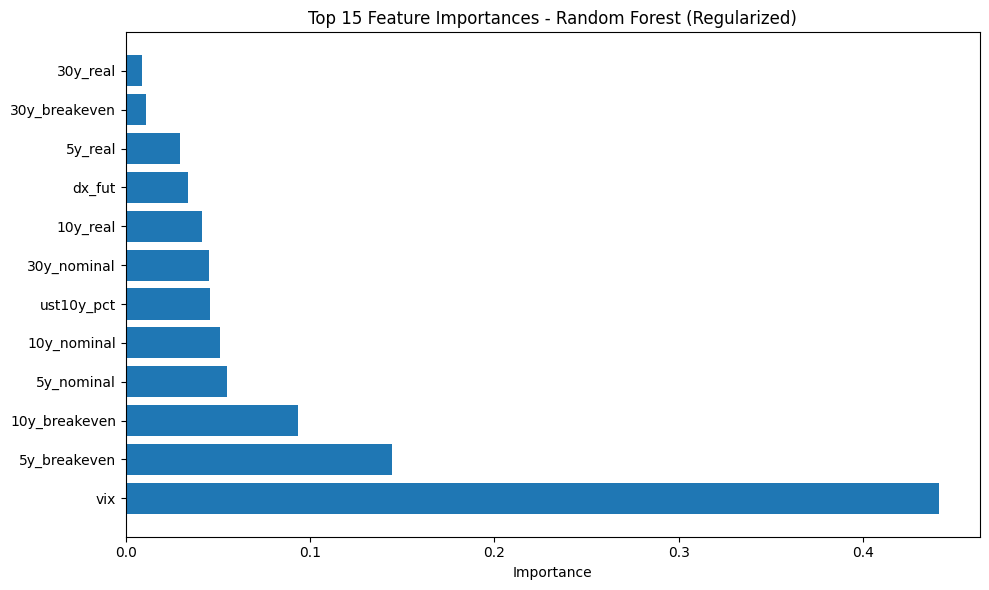

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Train Random Forest model with regularization to reduce overfitting
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=10,  # Reduce from 20
    min_samples_split=10,  # Increase from default (2)
    min_samples_leaf=5,  # Increase from default (1)
    max_features='sqrt',  # Use sqrt of features instead of all
    bootstrap=True,
    oob_score=True  # Out-of-bag score for validation
)
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluate on training set
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Evaluate on test set
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"{'='*60}")
print(f"RANDOM FOREST MODEL PERFORMANCE (Regularized)")
print(f"{'='*60}")
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")

print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")

print(f"\nOverfitting Gap (Train R² - Test R²): {train_r2 - test_r2:.4f}")
print(f"OOB Score: {rf_model.oob_score_:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest (Regularized)')
plt.tight_layout()
plt.show()

XGBOOST MODEL PERFORMANCE (Regularized)

Training Set:
  R² Score: 0.7501
  RMSE: 0.9820
  MAE: 0.4602

Test Set:
  R² Score: 0.2750
  RMSE: 2.3891
  MAE: 1.2414

Overfitting Gap (Train R² - Test R²): 0.4751

Top 15 Most Important Features:
          feature  importance
0             vix    0.560160
9    5y_breakeven    0.117244
3      5y_nominal    0.071398
10  10y_breakeven    0.040048
1      ust10y_pct    0.039728
11  30y_breakeven    0.036444
4     10y_nominal    0.032338
2          dx_fut    0.029421
5     30y_nominal    0.027512
7        10y_real    0.017166
8        30y_real    0.017125
6         5y_real    0.011415


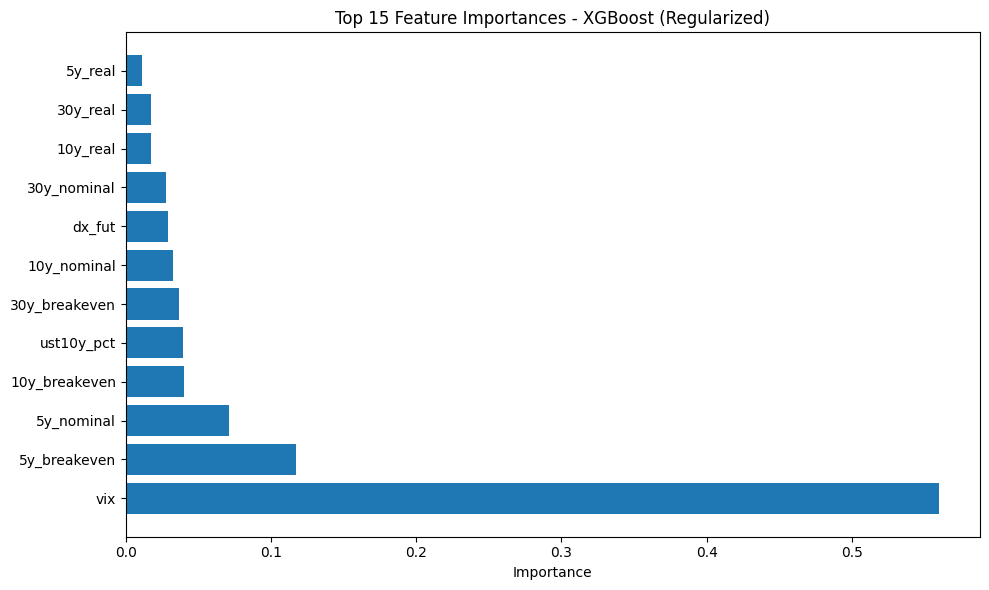

In [18]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Train XGBoost model with regularization to reduce overfitting
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=4,  # Reduce from 6
    learning_rate=0.05,  # Reduce from 0.1
    subsample=0.8,  # Use 80% of samples for each tree
    colsample_bytree=0.8,  # Use 80% of features for each tree
    reg_alpha=1.0,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    min_child_weight=5,  # Increase from default (1)
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Evaluate on training set
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Evaluate on test set
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"{'='*60}")
print(f"XGBOOST MODEL PERFORMANCE (Regularized)")
print(f"{'='*60}")
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")

print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")

print(f"\nOverfitting Gap (Train R² - Test R²): {train_r2 - test_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost (Regularized)')
plt.tight_layout()
plt.show()

# RF but with y variables separate

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Get individual target columns
target_vars = [col for col in target_cols]

# Dictionary to store models
models = {}
results = {}

for target_var in target_vars:
    print(f"\n{'='*60}")
    print(f"Training model for: {target_var}")
    print(f"{'='*60}")
    
    # Create y for this specific target
    y_single = combined_df[[target_var]].fillna(combined_df[target_var].mean())
    
    # Train-test split
    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X, y_single, test_size=0.2, shuffle=False
    )
    
    # Train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        bootstrap=True,
        oob_score=True
    )
    rf_model.fit(X_train_single, y_train_single.values.ravel())
    
    # Make predictions
    y_train_pred = rf_model.predict(X_train_single)
    y_test_pred = rf_model.predict(X_test_single)
    
    # Evaluate
    train_r2 = r2_score(y_train_single, y_train_pred)
    test_r2 = r2_score(y_test_single, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_single, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_single, y_test_pred))
    
    print(f"\nTraining Set - R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"Test Set - R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    print(f"Overfitting Gap: {train_r2 - test_r2:.4f}")
    
    # Store model and results
    models[target_var] = rf_model
    results[target_var] = {'train_r2': train_r2, 'test_r2': test_r2}
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 10 Features for {target_var}:")
    print(feature_importance.head(10))


Training model for: inflation_factor

Training Set - R²: 0.4775, RMSE: 0.1376
Test Set - R²: -0.0354, RMSE: 0.2227
Overfitting Gap: 0.5129

Top 10 Features for inflation_factor:
          feature  importance
9    5y_breakeven    0.177743
0             vix    0.121331
10  10y_breakeven    0.104597
1      ust10y_pct    0.103328
4     10y_nominal    0.087701
5     30y_nominal    0.083865
6         5y_real    0.083759
3      5y_nominal    0.073647
2          dx_fut    0.070471
7        10y_real    0.055726

Training model for: growth_factor

Training Set - R²: 0.4338, RMSE: 0.4733
Test Set - R²: 0.0488, RMSE: 1.8024
Overfitting Gap: 0.3851

Top 10 Features for growth_factor:
          feature  importance
9    5y_breakeven    0.134674
0             vix    0.133159
10  10y_breakeven    0.115706
2          dx_fut    0.101938
5     30y_nominal    0.098358
1      ust10y_pct    0.097864
4     10y_nominal    0.089072
3      5y_nominal    0.071740
6         5y_real    0.064915
7        10y_real  